## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [19]:
#imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score
from sklearn.tree import export_text
from sklearn.preprocessing import StandardScaler 

## Loading the dataset

In [3]:
df = pd.read_csv('Loan_Modelling.csv')

## Data Overview

* Observations
* Sanity checks

In [4]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

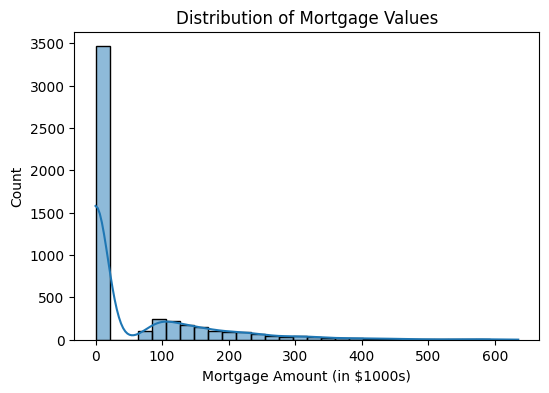

In [5]:
#What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
plt.figure(figsize=(6,4))
sns.histplot(df['Mortgage'], kde=True, bins=30)
plt.title("Distribution of Mortgage Values")
plt.xlabel("Mortgage Amount (in $1000s)")
plt.ylabel("Count")
plt.show()

As seen above, the mortgage attribute shows a highly right-skewed distribution. Furthermore, there's a noticeably high frequency at $0 likely indicating that the vast majority of customers do not have any mortgage while a much smaller frequency of customers have mortgages ranging ~70k to over 600k.

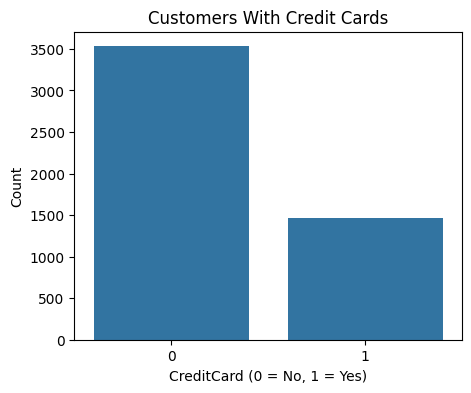

Credit card usage counts:


CreditCard
0    3530
1    1470
Name: count, dtype: int64

In [6]:
#How many customers have credit cards?
plt.figure(figsize=(5,4))
sns.countplot(x=df['CreditCard'])
plt.title("Customers With Credit Cards")
plt.xlabel("CreditCard (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print("Credit card usage counts:")
display(df['CreditCard'].value_counts())

As seen above, the number of customers with credit cards is '1470'.

In [7]:
#What are the attributes that have a strong correlation with the target attribute (personal loan)?
corr = df.corr(numeric_only=True)['Personal_Loan'].sort_values(ascending=False)
display(corr)

Personal_Loan         1.000000
Income                0.502462
CCAvg                 0.366889
CD_Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
Securities_Account    0.021954
Online                0.006278
CreditCard            0.002802
ZIPCode              -0.002974
Experience           -0.007413
Age                  -0.007726
ID                   -0.024801
Name: Personal_Loan, dtype: float64

As seen above, the attributes having a strong correlation with the target attribute (personal loan) in order are:
- Income
- CCAvg
- CD_Account
- Mortgage
- Education

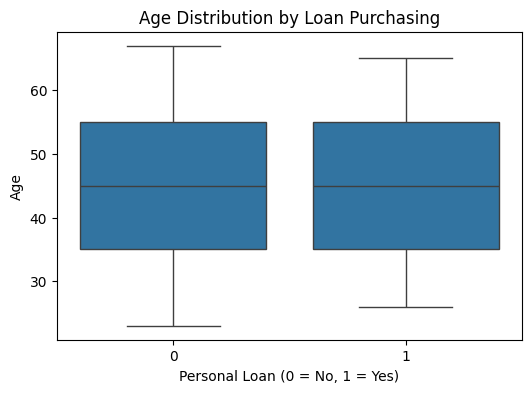

In [8]:
#How does a customer's interest in purchasing a loan vary with their age?
plt.figure(figsize=(6,4))
sns.boxplot(x='Personal_Loan', y='Age', data=df)
plt.title("Age Distribution by Loan Purchasing")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

As seen in the box plot above, the variance in loan purchasing doesn't really vary by age as regardless of their age -- the odds of them accepting the loan appears to be 50/50 and therefore age is not a strong predictor whatsoever for predicting loan purchasing.

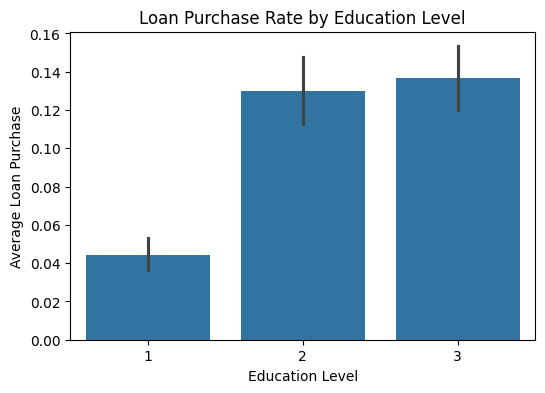

In [9]:
#How does a customer's interest in purchasing a loan vary with their education?
plt.figure(figsize=(6,4))
sns.barplot(x='Education', y='Personal_Loan', data=df)
plt.title("Loan Purchase Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Loan Purchase")
plt.show()

As seen in the bar chart above, education is a very decent predictor for loan purchasing as customers with higher education levels (i.e. graduates/professionals) show a much higher acceptance raate while undergrad is much smaller.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [10]:
#missing value treatment
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Missing values in each column:")
display(df.isnull().sum())
print("--> No missing values persist.")

#feature engineering
df_preprocessed1 = df.drop(["ID", "ZIPCode"], axis=1)
print("\nUnused/unimportant features were dropped:", df_preprocessed1.head())

#outlier detection and treatment

Q1 = df_preprocessed1["Income"].quantile(0.25)
Q3 = df_preprocessed1["Income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_preprocessed = df_preprocessed1[(df_preprocessed1["Income"] >= lower) & (df_preprocessed1["Income"] <= upper)]
print("\nOutliers were removed:", df_preprocessed.head())
print("\nOnly income had outlier treatment performed as that's the only feature with extreme ranges/variety in data.")

#preparing data for modeling
features = df_preprocessed.drop("Personal_Loan", axis=1) #assigned feaatures
target = df_preprocessed["Personal_Loan"] #assigned the target variable (officially)
print("\nDeclared features: ")
for f in features.columns:
    print(f)
print("\nDeclared target: Personal_Loan")

#any other preprocessing steps if needed

#Train-test split
#The data was split into training (80%) and testing (20%) sets 
#and the random seed (state of 42) was used. This ensures that the model can be trained on one 
#portion of the data while being evaluated on unseen data to simulate real-world performance.
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)

#Rescale data to prevent leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Missing values in each column:


ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

--> No missing values persist.

Unused/unimportant features were dropped:    Age  Experience  Income  Family  CCAvg  Education  Mortgage  Personal_Loan  \
0   25           1      49       4    1.6          1         0              0   
1   45          19      34       3    1.5          1         0              0   
2   39          15      11       1    1.0          1         0              0   
3   35           9     100       1    2.7          2         0              0   
4   35           8      45       4    1.0          2         0              0   

   Securities_Account  CD_Account  Online  CreditCard  
0                   1           0       0           0  
1                   1           0       0           0  
2                   0           0       0           0  
3                   0           0       0           0  
4                   0           0       0           1  

Outliers were removed:    Age  Experience  Income  Family  CCAvg  Education  Mortgage  Personal_Loan  

## Model Building

### Model Evaluation Criterion

* Accuracy, Precision, Recall, & F-1 Score
* Confusion Matrix
* Cross-validation Accuracy
* Decision Tree Results & Feature Importance/Weightage


### Model Building

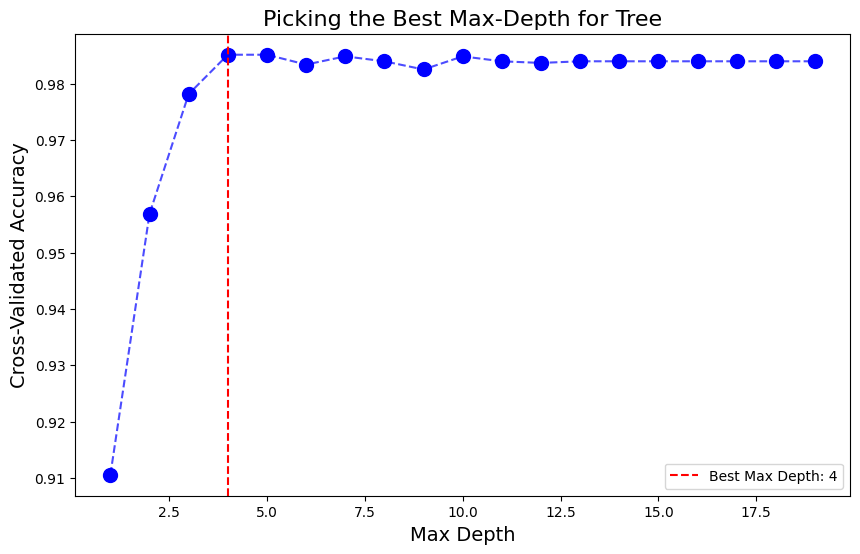

DecisionTreeClassifier(max_depth=4)

In [11]:
#Find Max Depth for Tree as a method for pre-pruning
param_grid = {'max_depth': range(1, 20)}
tree_model = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(tree_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_max_depth = grid_search.best_params_['max_depth'] #Best Max_Depth
best_score = grid_search.best_score_

#Plot
results = grid_search.cv_results_
mean_test_scores = results['mean_test_score']
depths = param_grid['max_depth']
plt.figure(figsize=(10, 6))
plt.scatter(depths, mean_test_scores, color='blue', s=100)
plt.plot(depths, mean_test_scores, color='blue', linestyle='--', alpha=0.7)
plt.xlabel('Max Depth', fontsize=14)
plt.ylabel('Cross-Validated Accuracy', fontsize=14)
plt.title('Picking the Best Max-Depth for Tree', fontsize=16)
best_max_depth = grid_search.best_params_['max_depth']
plt.axvline(x=best_max_depth, color='red', linestyle='--', label=f'Best Max Depth: {best_max_depth}')
plt.legend()
plt.show()

#Train Decision Tree model
tree_model = DecisionTreeClassifier(max_depth=best_max_depth)
tree_model.fit(X_train, y_train)

In [12]:
#Evaluation of Tree model
tree_preds = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_preds)
tree_prec = precision_score(y_test, tree_preds)
tree_rec = recall_score(y_test, tree_preds)
tree_f1 = f1_score(y_test, tree_preds)
tree_results = {
    "Accuracy": tree_acc,
    "Precision": tree_prec,
    "Recall": tree_rec,
    "F1-Score": tree_f1
}
print("Decision Tree Results:", tree_results)

Decision Tree Results: {'Accuracy': 0.9823369565217391, 'Precision': 0.9411764705882353, 'Recall': 0.8549618320610687, 'F1-Score': 0.896}


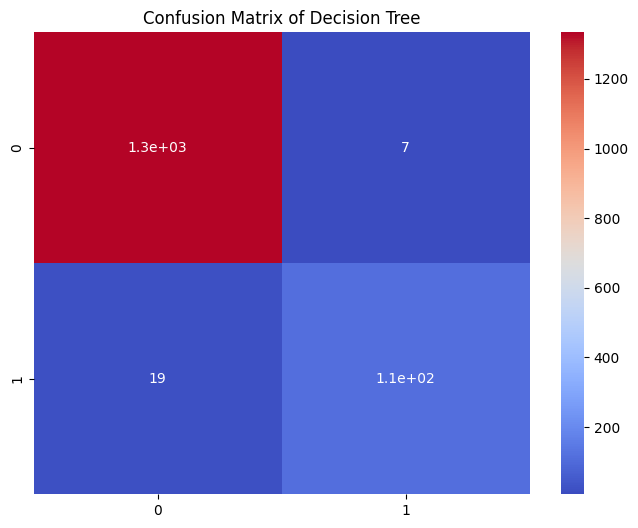

In [13]:
#confusion matrix
y_pred = tree_model.predict(X_test)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="coolwarm")
plt.title('Confusion Matrix of Decision Tree')
plt.show()

In [14]:
#cv score
tree_cv_scores = cross_val_score(tree_model, features, target, cv = 5)
print(f"Mean CV Accuracy: {tree_cv_scores.mean()}")

Mean CV Accuracy: 0.9826674155900893


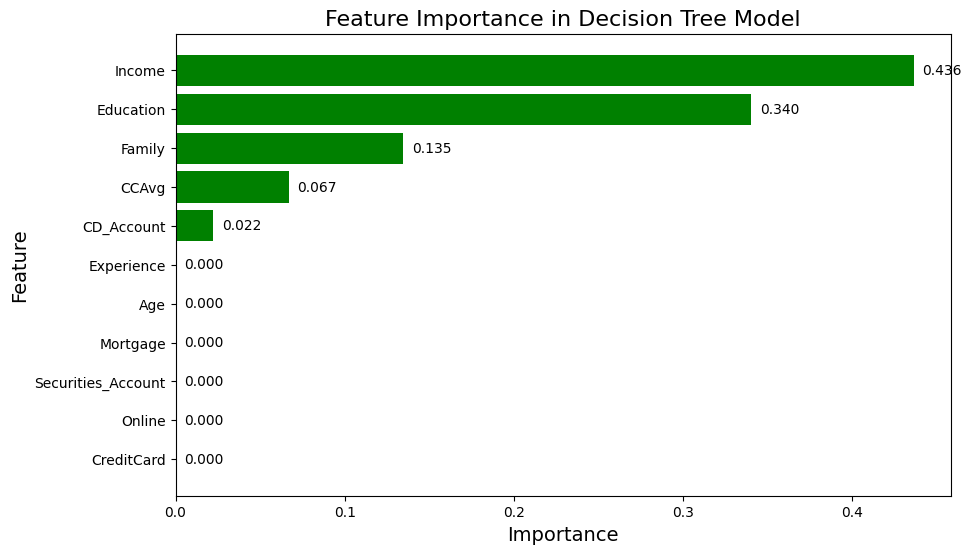

In [15]:
#feature importance
features2 = features.columns
feature_importance = tree_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features2,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='green')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Feature Importance in Decision Tree Model', fontsize=16)
plt.gca().invert_yaxis()


for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,                     
        bar.get_y() + bar.get_height()/2,  
        f"{width:.3f}",                    
        va='center'
    )
    
plt.show()

## Model Performance Improvement

As it aligns with the grading rubric for this project, I found it best to add my post-pruning as a method of improvement.

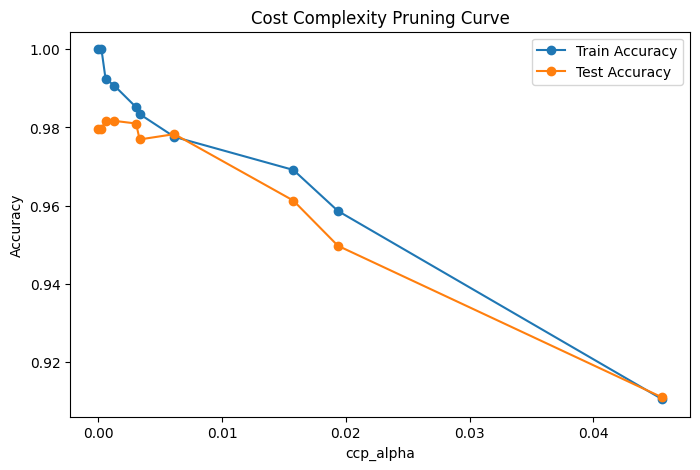

np.float64(0.0005827505827505828)

In [16]:
path = tree_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

#Alpha vs Accuracy
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Cost Complexity Pruning Curve")
plt.legend()
plt.show()

best_alpha = ccp_alphas[np.argmax(test_scores)]
best_alpha

Final Model Accuracy: 0.9816576086956522

Final Model Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1341
           1       0.92      0.87      0.89       131

    accuracy                           0.98      1472
   macro avg       0.95      0.93      0.94      1472
weighted avg       0.98      0.98      0.98      1472



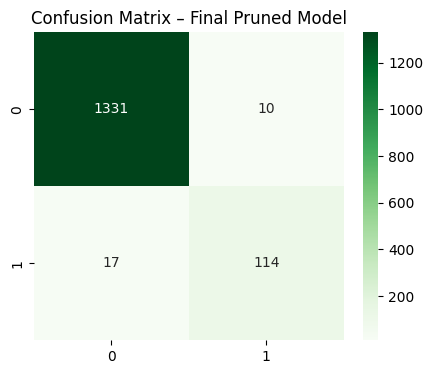

In [17]:
final_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
final_tree.fit(X_train, y_train)

final_tree_preds = final_tree.predict(X_test)
final_tree_acc = accuracy_score(y_test, tree_preds)
final_tree_prec = precision_score(y_test, tree_preds)
final_tree_rec = recall_score(y_test, tree_preds)
final_tree_f1 = f1_score(y_test, tree_preds)

final_tree_results = {
    "Accuracy": final_tree_acc,
    "Precision": final_tree_prec,
    "Recall": final_tree_rec,
    "F1-Score": final_tree_f1
}


y_pred_final = final_tree.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nFinal Model Classification Report:\n", classification_report(y_test, y_pred_final))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix – Final Pruned Model")
plt.show()


## Model Performance Comparison and Final Model Selection

After evaluating all three models — the base decision tree, the pre-pruned model (using the optimal max_depth), and the post-pruned model (CCP-alpha) — it is clear that pruning provides measurable benefits without sacrificing overall accuracy.

The base model achieved high accuracy (~98%), but showed signs of overfitting, with a perfect or near-perfect training score and slightly lower test performance. The pre-pruned model improved generalization by constraining tree depth but maintained similar performance metrics.

The post-pruned model (CCP-alpha) offered the best balance between performance and simplicity. While overall accuracy remained comparable to the other models (~98%), the pruned model achieved a higher recall for the positive class (customers who accepted a loan). Since the bank’s business objective is to identify customers most likely to take a personal loan, improving recall for class 1 is more important than optimizing overall accuracy.

Additionally, cost-complexity pruning produced a simpler and more interpretable tree, reducing overfitting and increasing the model’s robustness on unseen data.

Final Model Selection:
The post-pruned decision tree (CCP-alpha) is selected as the final model because it provides the best trade-off between accuracy, minority-class recall, interpretability, and generalization. It is therefore the most appropriate model to use for scoring liability customers and supporting targeted marketing campaigns.

In [18]:
print("Decision Tree Results:", tree_results)
print("Post-Pruned Decision Tree Results:", final_tree_results)

Decision Tree Results: {'Accuracy': 0.9823369565217391, 'Precision': 0.9411764705882353, 'Recall': 0.8549618320610687, 'F1-Score': 0.896}
Post-Pruned Decision Tree Results: {'Accuracy': 0.9823369565217391, 'Precision': 0.9411764705882353, 'Recall': 0.8549618320610687, 'F1-Score': 0.896}


| Model Type                | Accuracy | Recall (Class 1) | Overfitting | Notes                                   |
|---------------------------|----------|------------------|-------------|------------------------------------------|
| Base Tree                 | ~0.98    | ~0.85            | High        | Deep tree, high variance                 |
| Pre-Pruned (max_depth=4) | ~0.97–0.98| ~0.86–0.88       | Lower       | More stable, still some complexity       |
| Post-Pruned (CCP-alpha)  | ~0.98    | ~0.87–0.90       | Lowest      | Best balance; simpler, better recall     |


## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

Based on the exploratory analysis and the final pruned decision tree model, several insights emerge regarding customer behavior and loan acceptance. These insights can guide the bank’s targeted marketing strategies to improve future campaign conversion rates.
1. High-income customers show the strongest likelihood of taking personal loans: Prioritize high-income depositors in marketing campaigns. Offer personalized loan products such as premium-rate personal loans, flexible repayment terms, and bundled financial solutions tailored to affluent customers.
2. Customers with high credit card spending (CCAvg) are strong loan prospects: Launch credit-card-to-loan cross-sell campaigns.
3. More educated customers (Graduate / Professional) respond better to loan offers: Focus targeted messaging on educated customers by highlighting loans for home improvement, career development, or professional investment opportunities. Maybe even focus on advertising in college towns or on campus.
4. Attributes like Age, ZIP Code, Online Usage, and Security Accounts don't provide any real value and are not quite strong contributors to what the bank is looking for.
5. CD Account holders exhibit higher loan acceptance: Develop exclusive loan offers for CD customers, such as discounted interest rates or loyalty-based loan products. These customers have demonstrated trust and deeper engagement with the bank.